In [1]:
from cocohirf.experiment.custom_experiment import CustomCoClusteringExperiment, HPOCustomCoClusteringExperiment, HPOCustomVeCoHiRFExperiment
from cohirf.experiment.custom_clustering_experiment import CustomClusteringExperiment
from cohirf.experiment.hpo_custom_clustering_experiment import HPOCustomClusteringExperiment
from sklearn.datasets import make_classification
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from ml_experiments.utils import unflatten_any, flatten_any, update_recursively
from cohirf.models.vecohirf import VeCoHiRF
from cocohirf.experiment.tested_models import two_stage_models_dict
import numpy as np
import matplotlib as mpl
from pathlib import Path
from copy import deepcopy
import pandas as pd
from cohirf.experiment.spherical_clustering_experiment import generate_spherical_clusters
from cohirf.models.vecohirf import VeCoHiRF
from cohirf.models.cohirf import BaseCoHiRF
from sklearn.cluster import KMeans, DBSCAN
from cocohirf.experiment.tested_models import two_stage_models_dict, models_dict
import optuna as opt
from functools import partial
from optuna import Study, Trial
from ml_experiments.base_experiment import BaseExperiment
from ml_experiments.tuners import OptunaTuner

In [2]:
def generate_blobs_on_spheres(
    mean_r,
    std,
    n_blobs_per_sphere,
    blob_separation=2.0,
    blob_std=0.3,
    num_points_per_blob=500,
    seed=None
):
    """
    Generate blob clusters projected onto concentric spherical surfaces.
    Each sphere contains multiple blob clusters that are linearly separable in 
    the tangent space but arranged on the sphere surface.
    
    Parameters:
        mean_r (list): List of mean radii for each sphere.
        std (float): Standard deviation for the radii of spheres.
        n_blobs_per_sphere (int or list): Number of blob clusters per sphere.
                                          If int, same for all spheres.
                                          If list, specific for each sphere.
        blob_separation (float): Separation between blob centers (in tangent space).
        blob_std (float): Standard deviation for points within each blob.
        num_points_per_blob (int): Number of points per blob cluster.
        seed (int): Random seed for reproducibility.
    
    Returns:
        np.ndarray: Array of shape (N, 3), where N is the total number of points.
        np.ndarray: Array of shape (N,), containing labels for each point.
    """
    generator = np.random.default_rng(seed)
    
    if isinstance(n_blobs_per_sphere, int):
        n_blobs_per_sphere = [n_blobs_per_sphere] * len(mean_r)
    
    data = []
    labels = []
    cluster_id = 0
    
    for sphere_idx, r in enumerate(mean_r):
        n_blobs = n_blobs_per_sphere[sphere_idx]
        
        # Generate blob centers in 2D (will be mapped to sphere)
        blob_centers_2d = generator.uniform(-blob_separation, blob_separation, size=(n_blobs, 2))
        
        for blob_idx in range(n_blobs):
            center_2d = blob_centers_2d[blob_idx]
            
            # Generate points around this center in 2D
            points_2d = generator.normal(
                loc=center_2d,
                scale=blob_std,
                size=(num_points_per_blob, 2)
            )
            
            # Map 2D points to sphere surface using stereographic projection
            # Convert to spherical coordinates
            u, v = points_2d[:, 0], points_2d[:, 1]
            
            # Map to sphere: use angular coordinates
            # Scale to reasonable angles
            scale_factor = 0.5  # Controls how spread out blobs are on sphere
            theta = np.pi/2 + u * scale_factor  # latitude
            phi = v * scale_factor  # longitude
            
            # Add radius variation
            radii = generator.normal(r, std, num_points_per_blob)
            
            # Convert to Cartesian
            x = radii * np.sin(theta) * np.cos(phi)
            y = radii * np.sin(theta) * np.sin(phi)
            z = radii * np.cos(theta)
            
            points_3d = np.column_stack((x, y, z))
            data.append(points_3d)
            labels.extend([cluster_id] * num_points_per_blob)
            cluster_id += 1
    
    # Combine and shuffle
    data = np.vstack(data)
    labels = np.array(labels)
    perm = generator.permutation(data.shape[0])
    
    return data[perm], labels[perm]


def generate_linearly_partitioned_spheres(
    mean_r,
    std,
    num_points_per_sphere=1000,
    n_partitions=2,
    partition_offset=0.0,
    seed=None
):
    """
    Generate concentric spheres with additional linear hyperplane partitions.
    Each sphere is cut by hyperplanes, creating sub-clusters that are both
    spherically structured AND linearly separable.
    
    Parameters:
        mean_r (list): List of mean radii for each sphere.
        std (float): Standard deviation for the radii.
        num_points_per_sphere (int): Number of points to generate per sphere.
        n_partitions (int): Number of linear partitions (hyperplanes) to apply.
                           Creates 2^n_partitions sub-clusters per sphere.
        partition_offset (float): Offset of partition planes from origin.
        seed (int): Random seed for reproducibility.
    
    Returns:
        np.ndarray: Array of shape (N, 3), where N is the total number of points.
        np.ndarray: Array of shape (N,), containing labels for each point.
    """
    generator = np.random.default_rng(seed)
    
    # Generate random partition hyperplanes (normal vectors)
    partition_normals = []
    for _ in range(n_partitions):
        # Random unit vector as hyperplane normal
        normal = generator.normal(0, 1, 3)
        normal = normal / np.linalg.norm(normal)
        partition_normals.append(normal)
    
    data = []
    labels = []
    
    for sphere_idx, r in enumerate(mean_r):
        # Generate points on this sphere
        radii = generator.normal(r, std, num_points_per_sphere)
        phi = generator.uniform(0, 2 * np.pi, num_points_per_sphere)
        theta = np.arccos(generator.uniform(-1, 1, num_points_per_sphere))
        
        x = radii * np.sin(theta) * np.cos(phi)
        y = radii * np.sin(theta) * np.sin(phi)
        z = radii * np.cos(theta)
        
        points = np.column_stack((x, y, z))
        
        # Assign labels based on which side of each hyperplane the point is on
        # This creates 2^n_partitions sub-clusters
        point_labels = np.zeros(num_points_per_sphere, dtype=int)
        
        for partition_idx, normal in enumerate(partition_normals):
            # Compute which side of hyperplane each point is on
            # (dot product with normal > offset means positive side)
            side = (points @ normal > partition_offset).astype(int)
            # Use binary encoding: each partition is a bit
            point_labels += side * (2 ** partition_idx)
        
        # Offset labels by sphere index and number of sub-clusters per sphere
        n_subclusters = 2 ** n_partitions
        point_labels += sphere_idx * n_subclusters
        
        data.append(points)
        labels.extend(point_labels)
    
    # Combine and shuffle
    data = np.vstack(data)
    labels = np.array(labels)
    perm = generator.permutation(data.shape[0])
    
    return data[perm], labels[perm]

In [3]:
def generate_spheres_with_blob_features(
    mean_r,
    std_r,
    num_points_per_sphere=1000,
    n_blob_clusters=3,
    n_blob_features=2,
    blob_cluster_std=1.0,
    blob_separation=3.0,
    seed=None
):
    """
    Generate dataset with BOTH spherical features AND blob features.
    Final clusters are the Cartesian product: each sphere × each blob = composite cluster.
    
    This tests whether algorithms can discover clusters requiring multiple feature groups:
    - Features [0, 1, 2]: 3D coordinates on concentric spheres (spherical structure)
    - Features [3, ...]: Additional features with blob/linear structure
    
    Parameters:
        mean_r (list): List of mean radii for each sphere.
        std_r (float): Standard deviation for sphere radii.
        num_points_per_sphere (int): Points to generate per sphere.
        n_blob_clusters (int): Number of blob clusters in additional features.
        n_blob_features (int): Number of additional blob features to generate.
        blob_cluster_std (float): Standard deviation for blob clusters.
        blob_separation (float): Separation between blob cluster centers.
        seed (int): Random seed.
    
    Returns:
        np.ndarray: Array of shape (N, 3+n_blob_features).
        np.ndarray: Labels array where label = sphere_id * n_blob_clusters + blob_id.
    """    
    generator = np.random.default_rng(seed)
    n_spheres = len(mean_r)
    
    # Total points
    n_samples = num_points_per_sphere * n_spheres
    
    # 1. Generate spherical features (features 0, 1, 2)
    spherical_data = []
    sphere_labels = []
    
    for sphere_idx, r in enumerate(mean_r):
        radii = generator.normal(r, std_r, num_points_per_sphere)
        phi = generator.uniform(0, 2 * np.pi, num_points_per_sphere)
        theta = np.arccos(generator.uniform(-1, 1, num_points_per_sphere))
        
        x = radii * np.sin(theta) * np.cos(phi)
        y = radii * np.sin(theta) * np.sin(phi)
        z = radii * np.cos(theta)
        
        spherical_data.append(np.column_stack((x, y, z)))
        sphere_labels.extend([sphere_idx] * num_points_per_sphere)
    
    spherical_data = np.vstack(spherical_data)
    sphere_labels = np.array(sphere_labels)
    
    # 2. Generate blob features (additional features 3, 4, ...)
    # Create blob cluster centers
    blob_centers = generator.uniform(
        -blob_separation, 
        blob_separation, 
        size=(n_blob_clusters, n_blob_features)
    )
    
    # Assign each point to a blob cluster (independent of sphere membership)
    blob_labels = generator.choice(n_blob_clusters, size=n_samples)
    
    # Generate blob features based on assigned cluster
    blob_data = np.zeros((n_samples, n_blob_features))
    for i in range(n_samples):
        cluster_id = blob_labels[i]
        blob_data[i] = generator.normal(
            loc=blob_centers[cluster_id],
            scale=blob_cluster_std
        )
    
    # 3. Combine features: [spherical features | blob features]
    X = np.hstack([spherical_data, blob_data])
    
    # 4. Create composite labels (Cartesian product)
    # Label = sphere_id * n_blob_clusters + blob_id
    y = sphere_labels * n_blob_clusters + blob_labels
    
    # 5. Shuffle
    perm = generator.permutation(n_samples)
    
    return X[perm], y[perm], sphere_labels[perm], blob_labels[perm]

In [4]:
def generate_spheres_with_make_classification(
    mean_r,  # [0.5, 1.0]
    std_r=0.01,
    n_informative=2,
    n_random=0,
    n_redundant=0,
    n_repeated=0,
    n_classes=2,
    class_sep=1.0,
    shift=None,
    scale=None,
    num_points_per_sphere=1000,
    seed=None,
):
    """
    Generate dataset with BOTH spherical features AND classification features from make_classification.
    Final clusters are the Cartesian product: each sphere × each class = composite cluster.

    This tests whether algorithms can discover clusters requiring multiple feature groups:
    - Features [0, 1, 2]: 3D coordinates on concentric spheres (spherical structure)
    - Features [3, ...]: Additional features with blob/linear structure

    Parameters:
        mean_r (list): List of mean radii for each sphere.
        std_r (float): Standard deviation for sphere radii.
        n_informative (int): Number of informative features for make_classification.
        n_random (int): Number of random features for make_classification.
        n_redundant (int): Number of redundant features for make_classification.
        n_repeated (int): Number of repeated features for make_classification.
        n_classes (int): Number of classes for make_classification.
        class_sep (float): Class separation for make_classification.
        shift (array-like): Shift for make_classification.
        scale (array-like): Scale for make_classification.
        num_points_per_sphere (int): Points to generate per sphere.
        seed (int): Random seed.

    Returns:
        np.ndarray: Array of shape (N, 3+n_blob_features).
        np.ndarray: Labels array where label = sphere_id * n_blob_clusters + blob_id.
    """
    generator = np.random.default_rng(seed)
    n_spheres = len(mean_r)

    # Total points
    n_samples = num_points_per_sphere * n_spheres

    # 1. Generate spherical features (features 0, 1, 2)
    spherical_data = []
    sphere_labels = []

    for sphere_idx, r in enumerate(mean_r):
        radii = generator.normal(r, std_r, num_points_per_sphere)
        phi = generator.uniform(0, 2 * np.pi, num_points_per_sphere)
        theta = np.arccos(generator.uniform(-1, 1, num_points_per_sphere))

        x = radii * np.sin(theta) * np.cos(phi)
        y = radii * np.sin(theta) * np.sin(phi)
        z = radii * np.cos(theta)

        spherical_data.append(np.column_stack((x, y, z)))
        sphere_labels.extend([sphere_idx] * num_points_per_sphere)

    spherical_data = np.vstack(spherical_data)
    sphere_labels = np.array(sphere_labels)

    X_cls, y_cls = make_classification(
        n_samples=n_samples,
        n_features=n_informative + n_redundant + n_repeated + n_random,
        n_informative=n_informative,
        n_redundant=n_redundant,
        n_repeated=n_repeated,
        n_classes=n_classes,
        class_sep=class_sep,
        shift=shift,
        scale=scale,
        random_state=seed,
        n_clusters_per_class=1,
        flip_y=0.0,
    )

    # 3. Combine features: [spherical features | blob features]
    X = np.hstack([spherical_data, X_cls])

    # 4. Create composite labels (Cartesian product)
    # Label = sphere_id * n_blob_clusters + blob_id
    y = sphere_labels * n_classes + y_cls
    # 5. Shuffle
    perm = generator.permutation(n_samples)

    return X[perm], y[perm], sphere_labels[perm], y_cls[perm]

# Hybrid Spherical-Linear Datasets

Three approaches to create datasets combining spherical geometry with linear separability:

## 1. Blobs Projected onto Spheres (`generate_blobs_on_spheres`)
Takes linearly-separable blob clusters and maps them onto spherical surfaces. Each sphere contains multiple blob clusters that maintain linear separability characteristics but are geometrically arranged on the sphere.

**Key idea**: Clusters that are both *on a sphere* AND *linearly separable* in tangent space.

### Parameters:
- `mean_r`: Radii for concentric spheres
- `n_blobs_per_sphere`: How many blob clusters per sphere
- `blob_separation`: Distance between blob centers (controls separability)
- `blob_std`: Spread of each blob

## 2. Linearly Partitioned Spheres (`generate_linearly_partitioned_spheres`)
Takes concentric spheres and cuts them with hyperplanes, creating sub-clusters within each sphere. Each sphere is divided into 2^n regions by n hyperplanes.

**Key idea**: Spherical structure *with* linear hyperplane cuts creating sub-clusters.

### Parameters:
- `mean_r`: Radii for concentric spheres  
- `n_partitions`: Number of hyperplanes (creates 2^n sub-clusters per sphere)
- `partition_offset`: Shifts hyperplanes from origin

## 3. Spheres with Blob Features (`generate_spheres_with_blob_features`)
Creates separate feature groups: spherical features (x, y, z) + blob features (additional dimensions). True clusters are the Cartesian product of sphere membership × blob membership.

**Key idea**: Multi-view clustering where *different feature subsets* capture *different structures*.

### Parameters:
- `mean_r`: Radii for concentric spheres
- `n_blob_clusters`: Number of blob clusters in additional features
- `n_blob_features`: Number of additional feature dimensions
- `blob_separation`: Separation between blob centers

### Example:
- 2 spheres × 3 blobs = 6 total clusters
- Features [0,1,2]: capture which sphere (radial structure)
- Features [3,4,...]: capture which blob (linear structure)
- True label requires BOTH feature groups!

All three create challenging datasets where clustering algorithms must handle mixed geometries!

Blobs on Spheres: 2000 points, 5 clusters
Cluster sizes: [400 400 400 400 400]


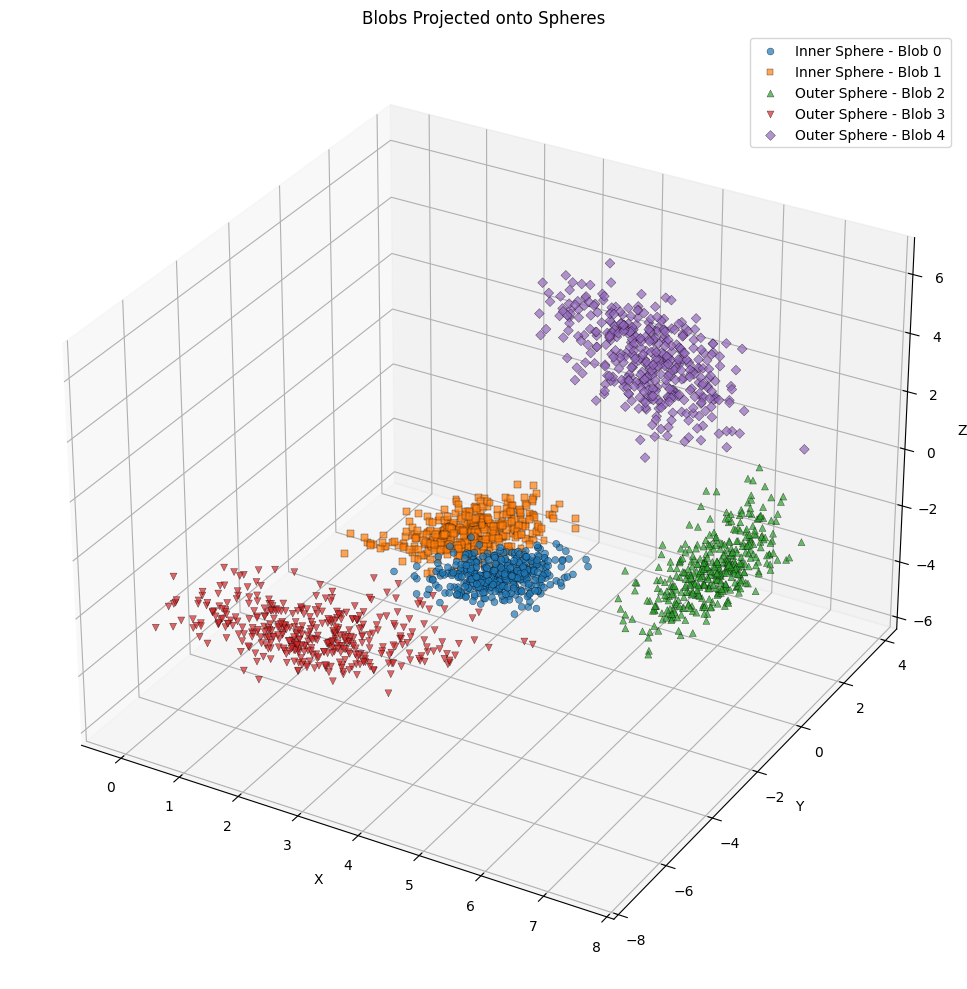

In [5]:
# Example 1: Blobs on Spheres
# Inner sphere with 2 blobs, outer sphere with 3 blobs
X_blobs_on_spheres, y_blobs_on_spheres = generate_blobs_on_spheres(
    mean_r=[5, 7],
    std=0.3,
    n_blobs_per_sphere=[2, 3],  # 2 blobs on inner, 3 on outer
    blob_separation=3.0,
    blob_std=0.3,
    num_points_per_blob=400,
    seed=42,
)

print(f"Blobs on Spheres: {X_blobs_on_spheres.shape[0]} points, {len(np.unique(y_blobs_on_spheres))} clusters")
print(f"Cluster sizes: {np.bincount(y_blobs_on_spheres)}")
# Visualize Blobs on Spheres
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

unique_labels = np.unique(y_blobs_on_spheres)
colors = plt.colormaps["tab10"].colors
markers = ["o", "s", "^", "v", "D", "P", "*", "X"]

for i, label in enumerate(unique_labels):
    mask = y_blobs_on_spheres == label
    sphere_id = "Inner" if label < 2 else "Outer"
    blob_id = label % 10  # Handle multiple blobs
    ax.scatter(
        X_blobs_on_spheres[mask, 0],
        X_blobs_on_spheres[mask, 1],
        X_blobs_on_spheres[mask, 2],
        c=[colors[i % len(colors)]],
        marker=markers[i % len(markers)],
        s=25,
        label=f"{sphere_id} Sphere - Blob {blob_id}",
        alpha=0.7,
        edgecolor='black',
        linewidth=0.3
    )

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Blobs Projected onto Spheres')
ax.legend()
plt.tight_layout()
plt.show()

Partitioned Spheres: 1600 points, 8 clusters
Cluster sizes: [262 147 144 247 265 133 151 251]


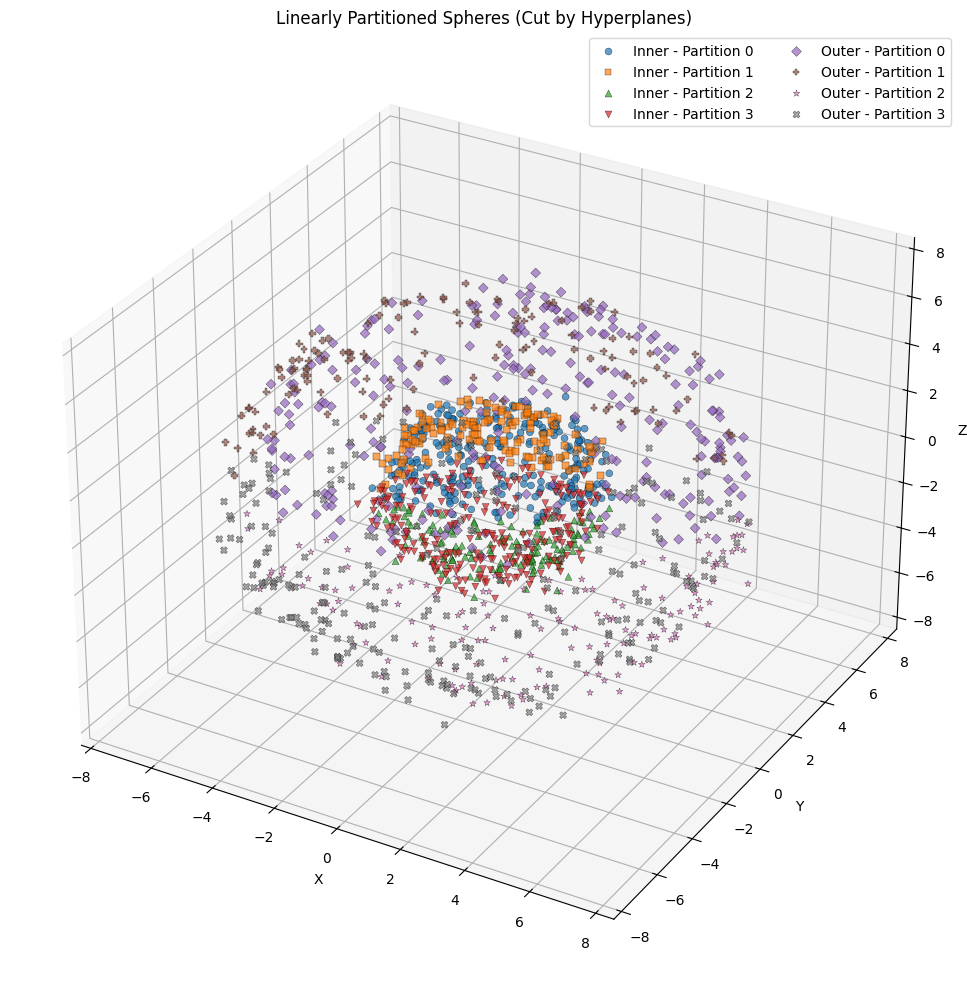

In [6]:
# Example 2: Linearly Partitioned Spheres
# Each sphere cut by 2 hyperplanes = 4 sub-clusters per sphere = 8 total clusters
X_partitioned, y_partitioned = generate_linearly_partitioned_spheres(
    mean_r=[3, 7],
    std=0.3,
    num_points_per_sphere=800,
    n_partitions=2,  # 2 hyperplanes -> 2^2 = 4 regions per sphere
    partition_offset=0.0,
    seed=42,
)

print(f"Partitioned Spheres: {X_partitioned.shape[0]} points, {len(np.unique(y_partitioned))} clusters")
print(f"Cluster sizes: {np.bincount(y_partitioned)}")
# Visualize Linearly Partitioned Spheres
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

unique_labels = np.unique(y_partitioned)
colors = plt.colormaps["tab10"].colors
markers = ["o", "s", "^", "v", "D", "P", "*", "X", "h", "p"]

for i, label in enumerate(unique_labels):
    mask = y_partitioned == label
    sphere_id = "Inner" if label < 4 else "Outer"
    partition_id = label % 4
    ax.scatter(
        X_partitioned[mask, 0],
        X_partitioned[mask, 1],
        X_partitioned[mask, 2],
        c=[colors[i % len(colors)]],
        marker=markers[i % len(markers)],
        s=25,
        label=f"{sphere_id} - Partition {partition_id}",
        alpha=0.7,
        edgecolor='black',
        linewidth=0.3
    )

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Linearly Partitioned Spheres (Cut by Hyperplanes)')
ax.legend(ncol=2)
plt.tight_layout()
plt.show()

## Key Differences

### 1. Blobs on Spheres
- **Geometry**: Blob clusters are *mapped onto* the sphere surface
- **Challenge**: Clusters follow spherical topology but maintain local linear separability
- **Best for**: Testing algorithms that need to handle manifold structure with local linearity
- **Example**: Social network communities (spherical structure) with sub-groups (blobs)

### 2. Linearly Partitioned Spheres  
- **Geometry**: Spheres are *cut by* hyperplanes
- **Challenge**: Global linear separability within spherical constraints
- **Best for**: Testing algorithms that need to find both radial and planar boundaries
- **Example**: Nested structures divided by decision boundaries (like hierarchical classification)

### 3. Spheres with Blob Features (NEW!)
- **Geometry**: Feature space partitioning - different feature subsets capture different structures
- **Challenge**: Multi-view clustering where true labels require **combining** feature groups
- **Best for**: Testing co-clustering algorithms that must integrate information from multiple agents/views
- **Example**: Medical diagnosis requiring both imaging features (spherical/spatial) and lab results (linear/numerical)
- **Perfect for VeCoHiRF**: Each agent sees different features, must collaborate to find true clusters!

Composite Dataset: 1200 points, 5 features
Spherical features: [0, 1, 2] - capture 2 spheres
Blob features: [3, 4] - capture 3 blobs
Composite clusters: 6 (2 spheres × 3 blobs)
Cluster sizes: [201 207 192 210 208 182]


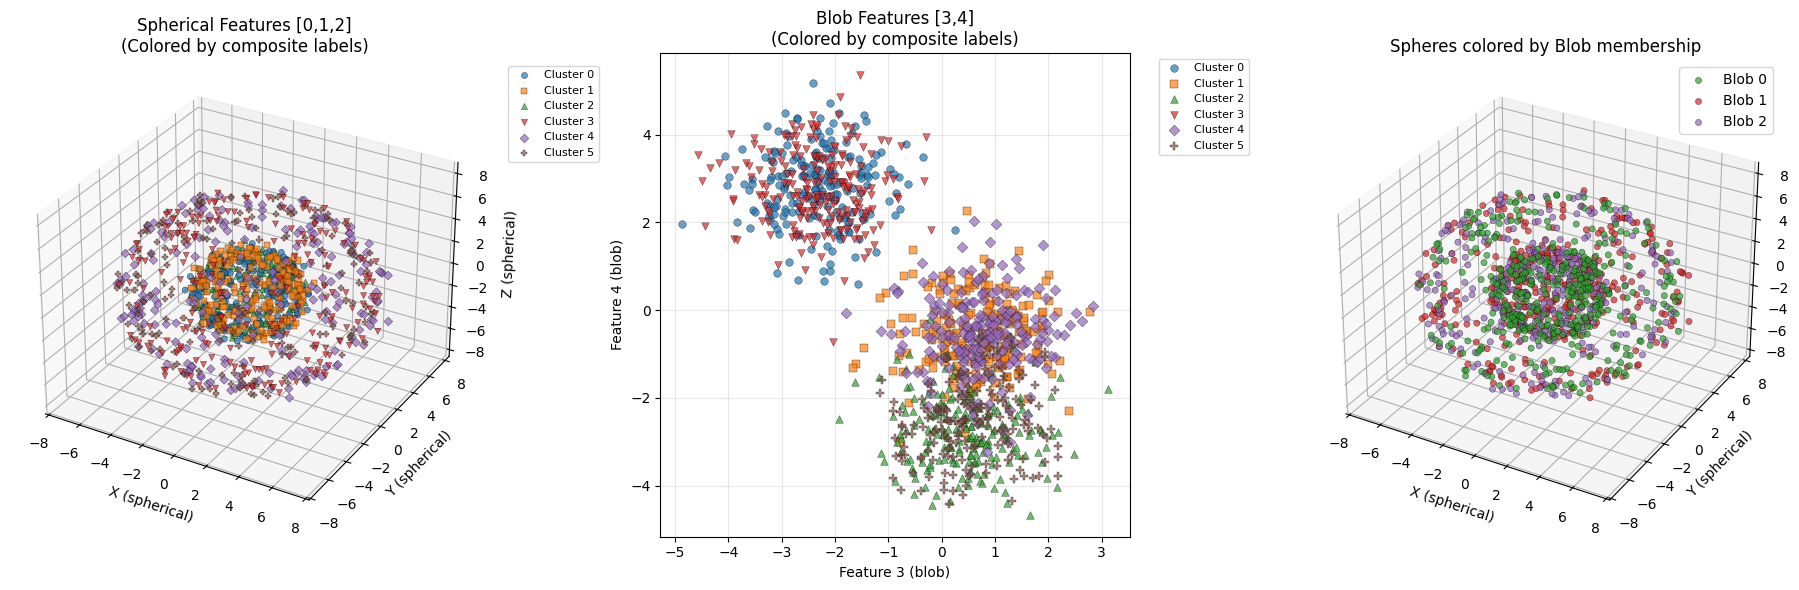

In [7]:
# Example 3: Spheres with Blob Features
# 2 spheres × 3 blobs = 6 composite clusters
X_composite, y_composite, sphere_labels, blob_labels = generate_spheres_with_blob_features(
    mean_r=[3, 7],
    std_r=0.3,
    num_points_per_sphere=600,
    n_blob_clusters=3,
    n_blob_features=2,  # Add 2 extra features for blobs
    blob_cluster_std=0.8,
    blob_separation=3.0,
    seed=42,
)

print(f"Composite Dataset: {X_composite.shape[0]} points, {X_composite.shape[1]} features")
print(f"Spherical features: [0, 1, 2] - capture 2 spheres")
print(f"Blob features: [3, 4] - capture 3 blobs")
print(f"Composite clusters: {len(np.unique(y_composite))} (2 spheres × 3 blobs)")
print(f"Cluster sizes: {np.bincount(y_composite)}")
# Visualize: Spherical features only (should see only 2 clusters)
fig = plt.figure(figsize=(18, 6))

# Plot 1: Using only spherical features [0,1,2] - colored by TRUE composite labels
ax1 = fig.add_subplot(131, projection='3d')
colors = plt.colormaps["tab10"].colors
markers = ["o", "s", "^", "v", "D", "P"]

for i, label in enumerate(np.unique(y_composite)):
    mask = y_composite == label
    ax1.scatter(
        X_composite[mask, 0],
        X_composite[mask, 1],
        X_composite[mask, 2],
        c=[colors[i % len(colors)]],
        marker=markers[i % len(markers)],
        s=20,
        label=f"Cluster {label}",
        alpha=0.7,
        edgecolor='black',
        linewidth=0.3
    )
ax1.set_xlabel('X (spherical)')
ax1.set_ylabel('Y (spherical)')
ax1.set_zlabel('Z (spherical)')
ax1.set_title('Spherical Features [0,1,2]\n(Colored by composite labels)')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

# Plot 2: Blob features only [3,4] - colored by TRUE composite labels
ax2 = fig.add_subplot(132)
for i, label in enumerate(np.unique(y_composite)):
    mask = y_composite == label
    ax2.scatter(
        X_composite[mask, 3],
        X_composite[mask, 4],
        c=[colors[i % len(colors)]],
        marker=markers[i % len(markers)],
        s=30,
        label=f"Cluster {label}",
        alpha=0.7,
        edgecolor='black',
        linewidth=0.3
    )
ax2.set_xlabel('Feature 3 (blob)')
ax2.set_ylabel('Feature 4 (blob)')
ax2.set_title('Blob Features [3,4]\n(Colored by composite labels)')
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax2.grid(True, alpha=0.3)

# Plot 3: Combined view - sphere structure with blob colors
ax3 = fig.add_subplot(133, projection='3d')
for i, blob_id in enumerate(np.unique(blob_labels)):
    mask = blob_labels == blob_id
    ax3.scatter(
        X_composite[mask, 0],
        X_composite[mask, 1],
        X_composite[mask, 2],
        c=[colors[(i + 2) % len(colors)]],
        s=20,
        label=f"Blob {blob_id}",
        alpha=0.7,
        edgecolor='black',
        linewidth=0.3
    )
ax3.set_xlabel('X (spherical)')
ax3.set_ylabel('Y (spherical)')
ax3.set_zlabel('Z (spherical)')
ax3.set_title('Spheres colored by Blob membership')
ax3.legend()

plt.tight_layout()
plt.show()

In [8]:
(3 * 2**0.5)*2

8.485281374238571

Composite Dataset: 1200 points, 5 features
Composite clusters: 6
Cluster sizes: [202 206 192 198 194 208]


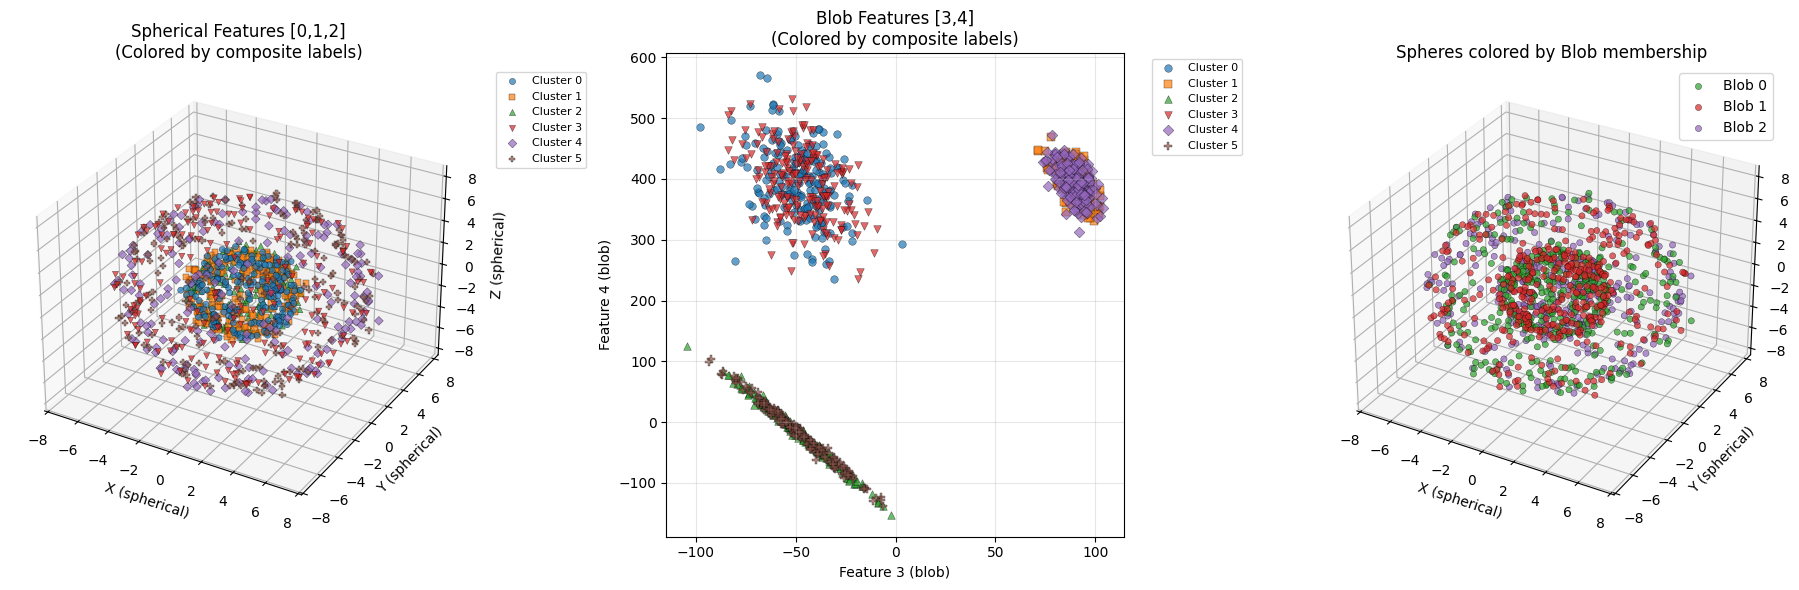

In [9]:
# Example 3: Spheres with Blob Features
# 2 spheres × 3 blobs = 6 composite clusters
X_composite, y_composite, sphere_labels, cls_labels = generate_spheres_with_make_classification(
    mean_r=[3, 7],
    std_r=0.3,
    num_points_per_sphere=600,
    n_informative=2,
    n_classes=3,
    class_sep=3*2**0.5,
    seed=42,
)

print(f"Composite Dataset: {X_composite.shape[0]} points, {X_composite.shape[1]} features")
print(f"Composite clusters: {len(np.unique(y_composite))}")
print(f"Cluster sizes: {np.bincount(y_composite)}")
# Visualize: Spherical features only (should see only 2 clusters)
fig = plt.figure(figsize=(18, 6))

# Plot 1: Using only spherical features [0,1,2] - colored by TRUE composite labels
ax1 = fig.add_subplot(131, projection="3d")
colors = plt.colormaps["tab10"].colors
markers = ["o", "s", "^", "v", "D", "P"]

for i, label in enumerate(np.unique(y_composite)):
    mask = y_composite == label
    ax1.scatter(
        X_composite[mask, 0],
        X_composite[mask, 1],
        X_composite[mask, 2],
        c=[colors[i % len(colors)]],
        marker=markers[i % len(markers)],
        s=20,
        label=f"Cluster {label}",
        alpha=0.7,
        edgecolor="black",
        linewidth=0.3,
    )
ax1.set_xlabel("X (spherical)")
ax1.set_ylabel("Y (spherical)")
ax1.set_zlabel("Z (spherical)")
ax1.set_title("Spherical Features [0,1,2]\n(Colored by composite labels)")
ax1.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)

# Plot 2: Blob features only [3,4] - colored by TRUE composite labels
ax2 = fig.add_subplot(132)
for i, label in enumerate(np.unique(y_composite)):
    mask = y_composite == label
    ax2.scatter(
        X_composite[mask, 3],
        X_composite[mask, 4],
        c=[colors[i % len(colors)]],
        marker=markers[i % len(markers)],
        s=30,
        label=f"Cluster {label}",
        alpha=0.7,
        edgecolor="black",
        linewidth=0.3,
    )
ax2.set_xlabel("Feature 3 (blob)")
ax2.set_ylabel("Feature 4 (blob)")
ax2.set_title("Blob Features [3,4]\n(Colored by composite labels)")
ax2.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
ax2.grid(True, alpha=0.3)

# Plot 3: Combined view - sphere structure with blob colors
ax3 = fig.add_subplot(133, projection="3d")
for i, blob_id in enumerate(np.unique(blob_labels)):
    mask = blob_labels == blob_id
    ax3.scatter(
        X_composite[mask, 0],
        X_composite[mask, 1],
        X_composite[mask, 2],
        c=[colors[(i + 2) % len(colors)]],
        s=20,
        label=f"Blob {blob_id}",
        alpha=0.7,
        edgecolor="black",
        linewidth=0.3,
    )
ax3.set_xlabel("X (spherical)")
ax3.set_ylabel("Y (spherical)")
ax3.set_zlabel("Z (spherical)")
ax3.set_title("Spheres colored by Blob membership")
ax3.legend()

plt.tight_layout()
plt.show()

---

## Summary: Three Hybrid Approaches

| Approach | Structure | Features | Clusters | Best For |
|----------|-----------|----------|----------|----------|
| **Blobs on Spheres** | Geometric embedding | 3D (x,y,z on sphere) | Blobs mapped to sphere surface | Manifold learning |
| **Partitioned Spheres** | Geometric cutting | 3D (x,y,z) | Spheres cut by hyperplanes | Mixed boundary types |
| **Spheres + Blob Features** | Feature space product | 3D + nD (separate groups) | Cartesian product: spheres × blobs | **Co-clustering / multi-view** |

The third approach is particularly powerful for **VeCoHiRF experiments** because it naturally models scenarios where different agents observe different feature modalities!

In [10]:
results_dir = Path("/home/belucci/code/cocohirf/results/custom")
results_dir.mkdir(parents=True, exist_ok=True)

In [11]:
mean_r = [0.5, 1.0]
std_r = 0.01
num_points_per_sphere = 1000
n_informative = 2
n_classes = 3
class_sep = 3 * 2**0.5
seed = 0
X, y, y_spheres, y_cls = generate_spheres_with_make_classification(
    mean_r=mean_r,
    std_r=std_r,
    num_points_per_sphere=num_points_per_sphere,
    n_informative=n_informative,
    n_classes=n_classes,
    class_sep=class_sep,
    seed=seed,
)
X = pd.DataFrame(X)
y_global = pd.Series(y)
y_spheres = pd.Series(y_spheres)
y_cls = pd.Series(y_cls)
y = [y_global, y_spheres, y_cls]

In [12]:
n_agents = 2
p_overlap = 0.0
sequential_split = False
n_trials = 20
n_trials_1 = 20
n_trials_2 = 10
hpo_metric = "adjusted_rand_mean"
direction = "maximize"
# equally split informative features among agents and distribute random features
spherical_features = [0, 1, 2]
cls_features = list(range(3, X.shape[1]))
features_groups = [spherical_features, cls_features]

In [13]:
model_cohirf_dbscan = BaseCoHiRF
model_params_cohirf_dbscan = dict(base_model=DBSCAN, n_features=4, repetitions=1, max_iter=1)
search_space_cohirf_dbscan = dict(
    base_model_kwargs=dict(
        eps=opt.distributions.FloatDistribution(1e-1, 10),
        min_samples=opt.distributions.IntDistribution(2, 50),
    ),
)
default_values_cohirf_dbscan = [
    dict(
        base_model_kwargs=dict(
            eps=0.5,
            min_samples=5,
        ),
    )
]
cohirf_dbscan = (
    model_cohirf_dbscan,
    model_params_cohirf_dbscan,
    search_space_cohirf_dbscan,
    default_values_cohirf_dbscan,
)
model_cohirf, model_params_cohirf, search_space_cohirf, default_values_cohirf = deepcopy(models_dict["CoHiRF"])
model_params_cohirf = update_recursively(model_params_cohirf, dict(max_iter=1))
cohirf = (model_cohirf, model_params_cohirf, search_space_cohirf, default_values_cohirf)
cohirf_models = [model_cohirf_dbscan, model_cohirf]
cohirf_params = [model_params_cohirf_dbscan, model_params_cohirf]
cohirf_search_spaces = [search_space_cohirf_dbscan, search_space_cohirf]
cohirf_default_values = [default_values_cohirf_dbscan, default_values_cohirf]

In [14]:
vecohirf_experiment = HPOCustomVeCoHiRFExperiment(
    # dataset
    X=X,
    y=y,
    n_agents=n_agents,
    p_overlap=p_overlap,
    sequential_split=sequential_split,
    features_groups=features_groups,
    # model
    cohirf_model=cohirf_models,
    cohirf_params=cohirf_params,
    cohirf_search_space=cohirf_search_spaces,
    cohirf_default_values=cohirf_default_values,
    vecohirf_model=VeCoHiRF,
    vecohirf_params=dict(
        cohirf_model=[deepcopy(model_cohirf_dbscan), deepcopy(model_cohirf)], cohirf_kwargs_shared=dict(max_iter=1)
    ),
    vecohirf_search_space=dict(),  # dict(cohirf_kwargs_shared=dict(random_state=opt.distributions.IntDistribution(0, int(1e6)))),
    vecohirf_default_values=[],
    n_trials_1=n_trials_1,
    n_trials_2=n_trials_2,
    # hpo
    hpo_seed=seed,
    hpo_metric_1=hpo_metric,
    hpo_metric_2=hpo_metric,
    direction_1=direction,
    direction_2=direction,
    calculate_metrics_even_if_too_many_clusters=True,
    # experiment
    raise_on_error=True,
    verbose=1,
)
vecohirf_result = vecohirf_experiment.run(return_results=True)[0]

Combinations completed:   0%|          | 0/1 [00:00<?, ?it/s]

Trials:   0%|          | 0/20 [00:00<?, ?it/s]

Trials:   0%|          | 0/20 [00:00<?, ?it/s]

Trials:   0%|          | 0/10 [00:00<?, ?it/s]

In [15]:
vecohirf_result["evaluate_model_return"]

{'best/n_clusters_0_': 6,
 'best/min_n_clusters': 6,
 'best/rand_score_mean': np.float64(1.0),
 'best/rand_score_std': np.float64(0.0),
 'best/adjusted_rand_mean': np.float64(1.0),
 'best/adjusted_rand_std': np.float64(0.0),
 'best/mutual_info_mean': np.float64(1.7913444464128907),
 'best/mutual_info_std': np.float64(0.0),
 'best/adjusted_mutual_info_mean': np.float64(1.0),
 'best/adjusted_mutual_info_std': np.float64(0.0),
 'best/normalized_mutual_info_mean': np.float64(1.0),
 'best/normalized_mutual_info_std': np.float64(0.0),
 'best/homogeneity_mean': np.float64(1.0),
 'best/homogeneity_std': np.float64(0.0),
 'best/completeness_mean': np.float64(1.0),
 'best/completeness_std': np.float64(0.0),
 'best/v_measure_mean': np.float64(1.0),
 'best/v_measure_std': np.float64(0.0),
 'best/silhouette_mean': np.float64(-0.00026487611944508196),
 'best/silhouette_std': np.float64(0.0),
 'best/calinski_harabasz_score_mean': np.float64(15230.783626553157),
 'best/calinski_harabasz_score_std': np

In [16]:
best_vecohirf_trial = vecohirf_result["fit_model_return"]["study"].best_trial
best_cohirf_trials = best_vecohirf_trial.params
cohirf_model_params = []
for name_trial, trial_index in best_cohirf_trials.items():
    agent_i = int(name_trial.split("_")[-1])
    best_trial = vecohirf_result["fit_model_return"]["studies_1"][agent_i].trials[trial_index]
    seed_model = best_trial.user_attrs["seed_model"]
    model_params = best_trial.user_attrs["model_params"]
    model_params["random_state"] = seed_model
    cohirf_model_params.append(model_params)

experiment = CustomCoClusteringExperiment(
    # dataset
    X=X,
    y=y,
    n_agents=n_agents,
    p_overlap=p_overlap,
    sequential_split=sequential_split,
    features_groups=features_groups,
    # model
    model=VeCoHiRF,
    model_params=dict(
        cohirf_model=cohirf_models,
        cohirf_kwargs_shared=dict(max_iter=1),
        cohirf_kwargs=cohirf_model_params,
    ),
    seed_model=0,
    # experiment
    raise_on_error=True,
    verbose=1,
)
result = experiment.run(return_results=True)[0]
vecohirf_ari = result["evaluate_model_return"]["adjusted_rand_mean"]
vecohirf_labels = result["fit_model_return"]["y_pred"]

Combinations completed:   0%|          | 0/1 [00:00<?, ?it/s]

In [17]:
best_vecohirf_trial = vecohirf_result["fit_model_return"]["study"].best_trial
best_cohirf_trials = best_vecohirf_trial.params
agent_labels = []
agent_aris = []
for name_trial, trial_index in best_cohirf_trials.items():
    agent_i = int(name_trial.split("_")[-1])
    best_trial = vecohirf_result["fit_model_return"]["studies_1"][agent_i].trials[trial_index]
    seed_model = best_trial.user_attrs["seed_model"]
    model_params = best_trial.user_attrs["model_params"]
    experiment = CustomClusteringExperiment(
        X=X.iloc[:, features_groups[agent_i]],
        y=y[0],
        model=cohirf_models[agent_i],
        model_params=model_params,
        seed_model=seed_model,
        raise_on_error=True,
        verbose=1,
    )
    result = experiment.run(return_results=True)[0]
    # ari = result["evaluate_model_return"]["adjusted_rand_mean"]
    ari = result["evaluate_model_return"]["adjusted_rand"]
    labels = result["fit_model_return"]["y_pred"]
    agent_labels.append(labels)
    agent_aris.append(ari)
    print(f"Agent {agent_i} CoHiRF best trial ARI: {ari:.4f}")

Combinations completed:   0%|          | 0/1 [00:00<?, ?it/s]

Agent 0 CoHiRF best trial ARI: 0.3331


Combinations completed:   0%|          | 0/1 [00:00<?, ?it/s]

Agent 1 CoHiRF best trial ARI: 0.5712


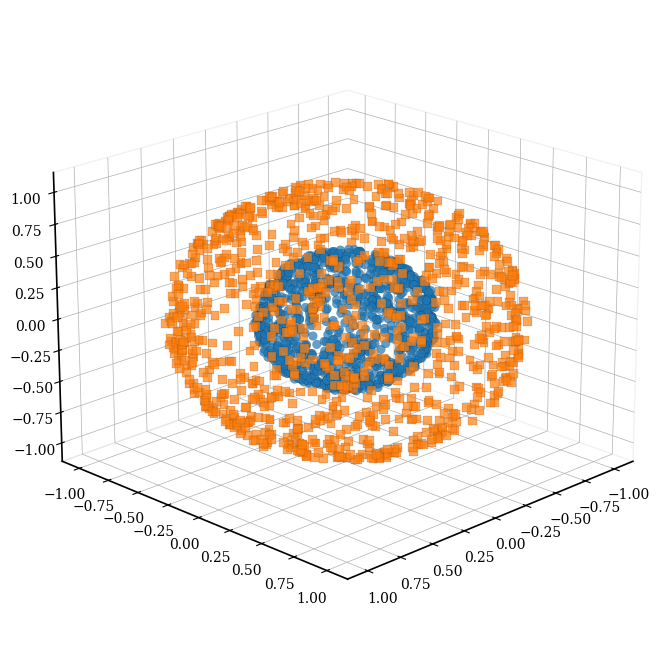

In [38]:
# plot agent 0 labels in shpere features
# Set up the figure with high DPI for publication quality
agent_i = 0
labels = agent_labels[agent_i]
features = X.iloc[:, spherical_features].to_numpy()
with mpl.rc_context(
    rc={
        "font.family": "serif",
        "font.serif": ["DejaVu Serif", "Liberation Serif", "Times", "serif"],  # Reliable serif fonts
        "mathtext.fontset": "dejavuserif",  # Use DejaVu for math text to avoid missing glyphs
        "axes.unicode_minus": False,  # Use ASCII minus instead of Unicode minus
        "font.size": 12,
        "axes.linewidth": 1.2,
        "axes.labelsize": 16,
        "axes.titlesize": 16,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
        "legend.frameon": True,
        "legend.fancybox": False,
        "legend.shadow": False,
        "legend.framealpha": 0.9,
        "legend.edgecolor": "black",
        "grid.alpha": 0.5,
        "axes.grid": True,
        "grid.linewidth": 0.5,
    }
):
    cm = 1 / 2.54  # centimeters to inches
    fig_scale = 3.0
    fig = plt.figure(figsize=(12 * fig_scale * cm, 7 * fig_scale * cm))
    ax = fig.add_subplot(111, projection="3d")

    # Define colors for each cluster (using colorblind-friendly palette)
    colors = plt.colormaps["tab10"].colors
    markers = ["o", "s", "^", "v", "D", "P", "*", "X", "p", "h"]  # circle, square, triangle, etc.

    unique_labels = np.unique(labels)

    # Plot each cluster with different colors
    for i, label in enumerate(unique_labels):
        mask = labels == label
        cluster_points = features[mask]
        ax.scatter(
            cluster_points[:, 0],
            cluster_points[:, 1],
            cluster_points[:, 2],
            c=[colors[i % len(colors)]],
            marker=markers[i % len(markers)],
            alpha=0.7,
            s=40,
            label=f"Cluster {label + 1}",
            edgecolors="black",
            linewidth=0.1,
        )

    # Set viewing angle for optimal visualization
    ax.view_init(elev=20, azim=45)

    # Make the plot look more professional
    ax.grid(True, alpha=0.3)
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False

    # Make pane edges more subtle
    ax.xaxis.pane.set_edgecolor("gray")
    ax.yaxis.pane.set_edgecolor("gray")
    ax.zaxis.pane.set_edgecolor("gray")
    ax.xaxis.pane.set_alpha(0.1)
    ax.yaxis.pane.set_alpha(0.1)
    ax.zaxis.pane.set_alpha(0.1)

    # set title - use fig.suptitle with y position for better control
    # fig.suptitle(f"Agent {agent_i} on Spherical Features - Global ARI: {agent_aris[agent_i]:.4f}", fontsize=14, y=0.85)
    
    fig.savefig(
        results_dir / f"vecohirf_agent_{agent_i}_spherical_features.pdf", bbox_inches="tight", dpi=600
    )

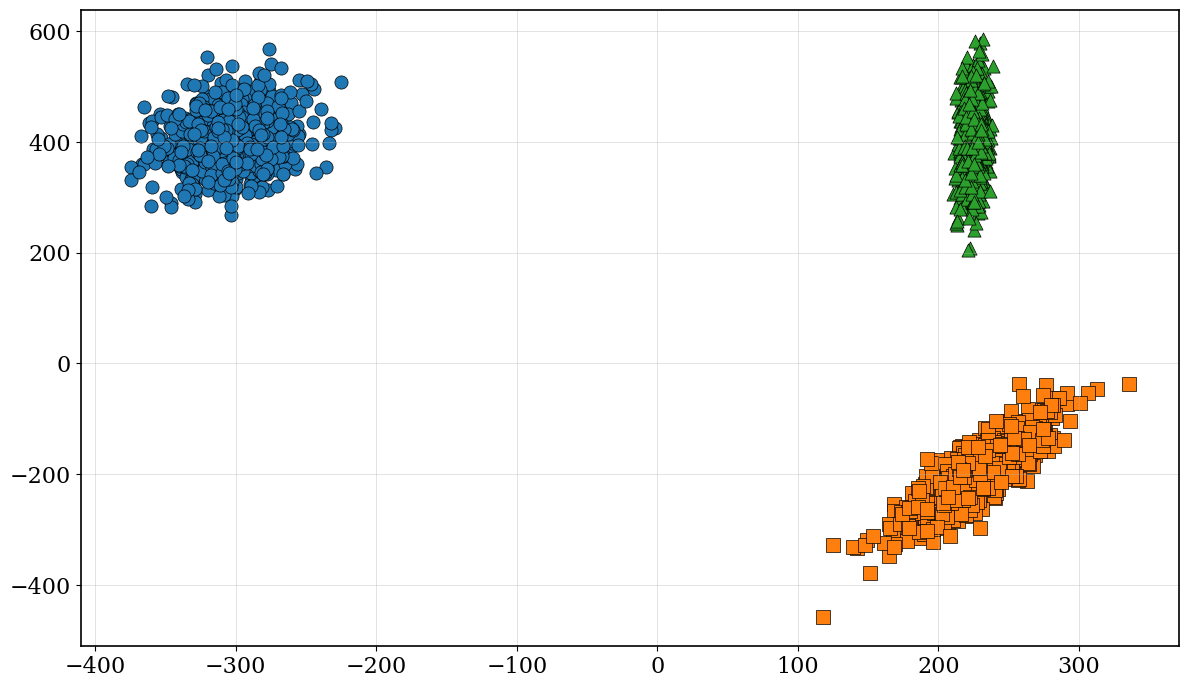

In [19]:
# plot agent 1 labels in classification features
agent_i = 1
labels = agent_labels[agent_i]
features = X.iloc[:, cls_features].to_numpy()
unique_labels = np.unique(labels)
with mpl.rc_context(
    rc={
        "font.family": "serif",
        "font.serif": ["DejaVu Serif", "Liberation Serif", "Times", "serif"],  # Reliable serif fonts
        "mathtext.fontset": "dejavuserif",  # Use DejaVu for math text to avoid missing glyphs
        "axes.unicode_minus": False,  # Use ASCII minus instead of Unicode minus
        "font.size": 12,
        "axes.linewidth": 1.2,
        "axes.labelsize": 16,
        "axes.titlesize": 16,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 10,
        "legend.frameon": True,
        "legend.fancybox": False,
        "legend.shadow": False,
        "legend.framealpha": 0.9,
        "legend.edgecolor": "black",
        "grid.alpha": 0.5,
        "axes.grid": True,
        "grid.linewidth": 0.5,
    }
):
    cm = 1 / 2.54  # centimeters to inches
    fig_scale = 3.0
    fig, ax = plt.subplots(figsize=(12 * fig_scale * cm, 7 * fig_scale * cm))
    # Create discrete colormap with only the colors you need
    n_clusters = len(np.unique(labels))
    colors = plt.colormaps["tab10"].colors
    markers = ["o", "s", "^", "v", "D", "P", "*", "X", "p", "h"]  # circle, square, triangle, etc.
    for i, label in enumerate(unique_labels):
        mask = labels == label
        ax.scatter(
            features[mask, 0],
            features[mask, 1],
            c=[colors[i % len(colors)]],
            marker=markers[i % len(markers)],
            s=90,
            label=f"Cluster {label}",
            edgecolor="black",
            linewidth=0.5,
        )
    # ax.set_title(f"Agent {agent_i} on Squared Features - Global ARI: {agent_aris[agent_i]:.4f}")
    fig.savefig(
        results_dir
        / f"vecohirf_agent_{agent_i}_classification_features.pdf",
        bbox_inches="tight",
    )

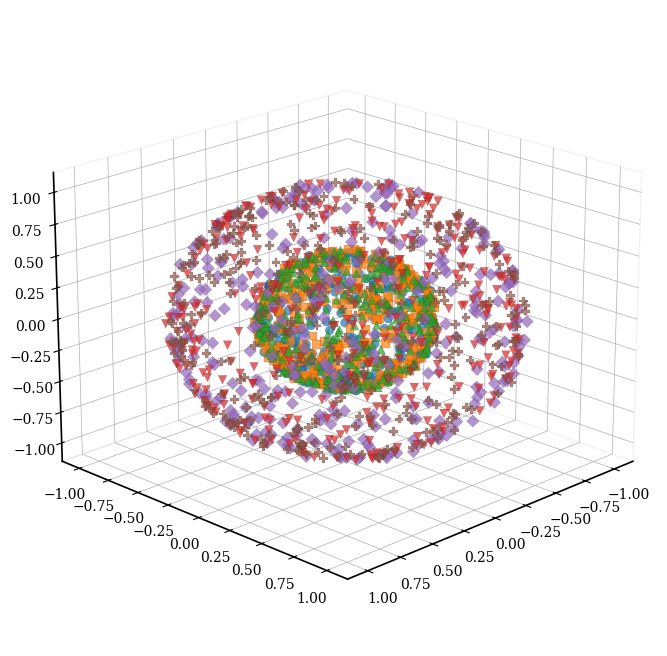

In [20]:
# plot VertCoHiRF labels in spherical features
# Set up the figure with high DPI for publication quality
labels = vecohirf_labels
features = X.iloc[:, spherical_features].to_numpy()
with mpl.rc_context(
    rc={
        "font.family": "serif",
        "font.serif": ["DejaVu Serif", "Liberation Serif", "Times", "serif"],  # Reliable serif fonts
        "mathtext.fontset": "dejavuserif",  # Use DejaVu for math text to avoid missing glyphs
        "axes.unicode_minus": False,  # Use ASCII minus instead of Unicode minus
        "font.size": 12,
        "axes.linewidth": 1.2,
        "axes.labelsize": 16,
        "axes.titlesize": 16,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
        "legend.frameon": True,
        "legend.fancybox": False,
        "legend.shadow": False,
        "legend.framealpha": 0.9,
        "legend.edgecolor": "black",
        "grid.alpha": 0.5,
        "axes.grid": True,
        "grid.linewidth": 0.5,
    }
):
    cm = 1 / 2.54  # centimeters to inches
    fig_scale = 3.0
    fig = plt.figure(figsize=(12 * fig_scale * cm, 7 * fig_scale * cm))
    ax = fig.add_subplot(111, projection="3d")

    # Define colors for each cluster (using colorblind-friendly palette)
    colors = plt.colormaps["tab10"].colors
    markers = ["o", "s", "^", "v", "D", "P", "*", "X", "p", "h"]  # circle, square, triangle, etc.

    unique_labels = np.unique(labels)

    # Plot each cluster with different colors
    for i, label in enumerate(unique_labels):
        mask = labels == label
        cluster_points = features[mask]
        ax.scatter(
            cluster_points[:, 0],
            cluster_points[:, 1],
            cluster_points[:, 2],
            c=[colors[i % len(colors)]],
            marker=markers[i % len(markers)],
            alpha=0.7,
            s=40,
            label=f"Cluster {label + 1}",
            edgecolors="black",
            linewidth=0.1,
        )

    # Set viewing angle for optimal visualization
    ax.view_init(elev=20, azim=45)

    # Make the plot look more professional
    ax.grid(True, alpha=0.3)
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False

    # Make pane edges more subtle
    ax.xaxis.pane.set_edgecolor("gray")
    ax.yaxis.pane.set_edgecolor("gray")
    ax.zaxis.pane.set_edgecolor("gray")
    ax.xaxis.pane.set_alpha(0.1)
    ax.yaxis.pane.set_alpha(0.1)
    ax.zaxis.pane.set_alpha(0.1)

    # set title - use fig.suptitle with y position for better control
    # fig.suptitle(f"VertCoHiRF on Spherical Features - Global ARI: {vecohirf_ari:.4f}", fontsize=14, y=0.85)
    fig.savefig(results_dir / f"vecohirf_spherical_features.pdf", bbox_inches="tight", dpi=600)

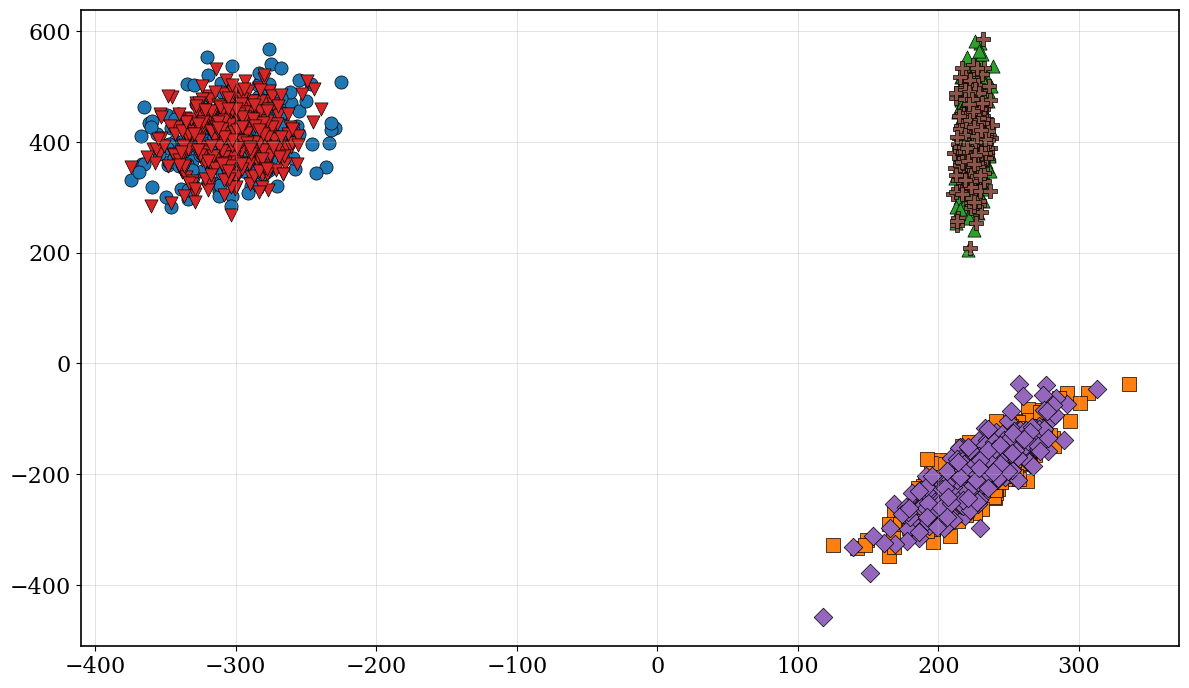

In [21]:
# plot vertcohirf labels in classification features
labels = vecohirf_labels
features = X.iloc[:, cls_features].to_numpy()
unique_labels = np.unique(labels)
with mpl.rc_context(
    rc={
        "font.family": "serif",
        "font.serif": ["DejaVu Serif", "Liberation Serif", "Times", "serif"],  # Reliable serif fonts
        "mathtext.fontset": "dejavuserif",  # Use DejaVu for math text to avoid missing glyphs
        "axes.unicode_minus": False,  # Use ASCII minus instead of Unicode minus
        "font.size": 12,
        "axes.linewidth": 1.2,
        "axes.labelsize": 16,
        "axes.titlesize": 16,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 10,
        "legend.frameon": True,
        "legend.fancybox": False,
        "legend.shadow": False,
        "legend.framealpha": 0.9,
        "legend.edgecolor": "black",
        "grid.alpha": 0.5,
        "axes.grid": True,
        "grid.linewidth": 0.5,
    }
):
    cm = 1 / 2.54  # centimeters to inches
    fig_scale = 3.0
    fig, ax = plt.subplots(figsize=(12 * fig_scale * cm, 7 * fig_scale * cm))
    # Create discrete colormap with only the colors you need
    n_clusters = len(np.unique(labels))
    colors = plt.colormaps["tab10"].colors
    markers = ["o", "s", "^", "v", "D", "P", "*", "X", "p", "h"]  # circle, square, triangle, etc.
    for i, label in enumerate(unique_labels):
        mask = labels == label
        ax.scatter(
            features[mask, 0],
            features[mask, 1],
            c=[colors[i % len(colors)]],
            marker=markers[i % len(markers)],
            s=90,
            label=f"Cluster {label}",
            edgecolor="black",
            linewidth=0.5,
        )
    # ax.set_title(f"VertCoHiRF on Squared Features - Global ARI: {vecohirf_ari:.4f}")
    fig.savefig(
        results_dir / f"vecohirf_classification_features.pdf",
        bbox_inches="tight",
    )